In [ ]:
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Concatenate,
    Dense,
    Dropout,
    Input,
    LayerNormalization,
    LSTM,
)
from tensorflow.keras.regularizers import l2


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

In [ ]:
DATA_PATH = Path("star_classification.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. "
        "Make sure the CSV is in the repository's main folder."
    )

df = pd.read_csv(DATA_PATH)

print("Original shape:", df.shape)
df.head()

Original shape: (100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [ ]:
print(df.columns.tolist())
print()
print(df.info())

['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  flo

In [ ]:
SEQUENCE_FEATURES = ["u", "g", "r", "i", "z"]
EXTRA_FEATURES = ["redshift"]
MODEL_FEATURES = SEQUENCE_FEATURES + EXTRA_FEATURES
TARGET = "class"

required_columns = MODEL_FEATURES + [TARGET]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

clean_df = df.copy()

clean_df = clean_df.drop_duplicates()

for column in MODEL_FEATURES:
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce",
    )

clean_df = clean_df.replace(
    [np.inf, -np.inf],
    np.nan,
)

clean_df = clean_df.dropna(
    subset=MODEL_FEATURES + [TARGET]
)

invalid_mask = clean_df[MODEL_FEATURES].eq(-9999).any(axis=1)
clean_df = clean_df.loc[~invalid_mask].copy()

clean_df = clean_df.reset_index(drop=True)

print("Cleaned shape:", clean_df.shape)
print()
print(clean_df[TARGET].value_counts())

Cleaned shape: (99999, 18)

class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64


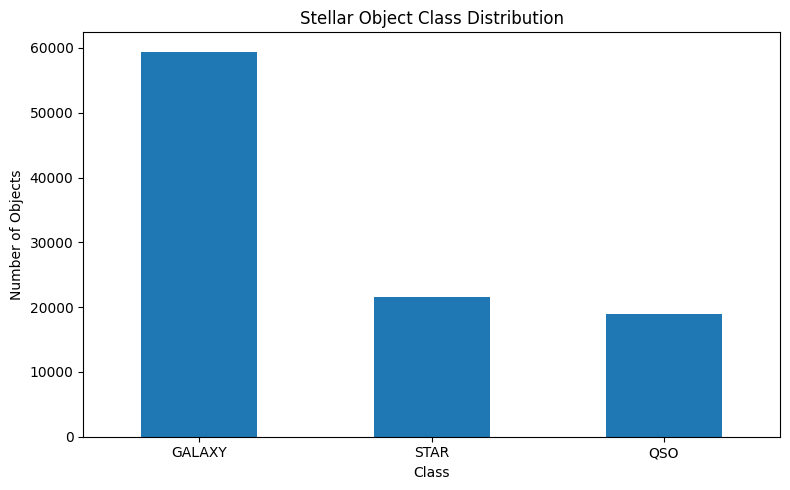

In [ ]:
class_counts = clean_df[TARGET].value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")

plt.title("Stellar Object Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Objects")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
label_encoder = LabelEncoder()

X = clean_df[MODEL_FEATURES].copy()
y = label_encoder.fit_transform(clean_df[TARGET])

class_mapping = {
    class_name: class_number
    for class_number, class_name
    in enumerate(label_encoder.classes_)
}

print("Class mapping:", class_mapping)
print("X shape:", X.shape)
print("y shape:", y.shape)

Class mapping: {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
X shape: (99999, 6)
y shape: (99999,)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED,
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED,
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_validation))
print("Test rows:", len(X_test))

Training rows: 69999
Validation rows: 15000
Test rows: 15000


In [ ]:
band_scaler = StandardScaler()
redshift_scaler = StandardScaler()

X_train_bands = band_scaler.fit_transform(
    X_train[SEQUENCE_FEATURES]
)

X_validation_bands = band_scaler.transform(
    X_validation[SEQUENCE_FEATURES]
)

X_test_bands = band_scaler.transform(
    X_test[SEQUENCE_FEATURES]
)

X_train_redshift = redshift_scaler.fit_transform(
    X_train[EXTRA_FEATURES]
)

X_validation_redshift = redshift_scaler.transform(
    X_validation[EXTRA_FEATURES]
)

X_test_redshift = redshift_scaler.transform(
    X_test[EXTRA_FEATURES]
)

In [ ]:
number_of_bands = len(SEQUENCE_FEATURES)

X_train_bands = X_train_bands.reshape(
    X_train_bands.shape[0],
    number_of_bands,
    1,
)

X_validation_bands = X_validation_bands.reshape(
    X_validation_bands.shape[0],
    number_of_bands,
    1,
)

X_test_bands = X_test_bands.reshape(
    X_test_bands.shape[0],
    number_of_bands,
    1,
)

print("Training sequence shape:", X_train_bands.shape)
print("Validation sequence shape:", X_validation_bands.shape)
print("Test sequence shape:", X_test_bands.shape)
print("Training redshift shape:", X_train_redshift.shape)

Training sequence shape: (69999, 5, 1)
Validation sequence shape: (15000, 5, 1)
Test sequence shape: (15000, 5, 1)
Training redshift shape: (69999, 1)


In [ ]:
class_numbers = np.unique(y_train)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=class_numbers,
    y=y_train,
)

class_weights = {
    int(class_number): float(weight)
    for class_number, weight
    in zip(class_numbers, class_weight_values)
}

print("Class weights:", class_weights)

Class weights: {0: 0.560741150176636, 1: 1.7579296315829127, 2: 1.5436983129341713}


In [ ]:
def build_lstm_model() -> Model:
    band_input = Input(
        shape=(number_of_bands, 1),
        name="photometric_bands",
    )

    band_features = LSTM(
        units=32,
        dropout=0.20,
        name="lstm",
    )(band_input)

    band_features = LayerNormalization(
        name="band_normalization"
    )(band_features)

    redshift_input = Input(
        shape=(1,),
        name="redshift",
    )

    redshift_features = Dense(
        units=8,
        activation="relu",
        name="redshift_dense",
    )(redshift_input)

    combined_features = Concatenate(
        name="combined_features"
    )([
        band_features,
        redshift_features,
    ])

    hidden = Dense(
        units=32,
        activation="relu",
        kernel_regularizer=l2(0.001),
        name="hidden_dense_1",
    )(combined_features)

    hidden = Dropout(
        rate=0.30,
        name="dropout",
    )(hidden)

    hidden = Dense(
        units=16,
        activation="relu",
        name="hidden_dense_2",
    )(hidden)

    output = Dense(
        units=len(label_encoder.classes_),
        activation="softmax",
        name="class_output",
    )(hidden)

    lstm_model = Model(
        inputs={
            "photometric_bands": band_input,
            "redshift": redshift_input,
        },
        outputs=output,
        name="stellar_lstm_classifier",
    )

    lstm_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return lstm_model


model = build_lstm_model()
model.summary()

Model: "stellar_lstm_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ photometric_bands   │ (None, 5, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      4,352 │ photometric_band… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ redshift            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ band_normalization  │ (None, 32)        │         64 │ lstm[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ redshift_dense      │ (None, 8)         │         16 │ redshift[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_features   │ (None, 40)        │          0 │ band_normalizati… │
│ (Concatenate)       │                   │            │ redshift_dense[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_dense_1      │ (None, 32)        │      1,312 │ combined_feature… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ hidden_dense_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_dense_2      │ (None, 16)        │        528 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 3)         │         51 │ hidden_dense_2[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,323 (24.70 KB)

 Trainable params: 6,323 (24.70 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

In [ ]:
history = model.fit(
    x={
        "photometric_bands": X_train_bands,
        "redshift": X_train_redshift,
    },
    y=y_train,
    validation_data=(
        {
            "photometric_bands": X_validation_bands,
            "redshift": X_validation_redshift,
        },
        y_validation,
    ),
    epochs=100,
    batch_size=128,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7688 - loss: 0.4949 - val_accuracy: 0.9127 - val_loss: 0.2722 - learning_rate: 0.0010
Epoch 2/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9263 - loss: 0.2319 - val_accuracy: 0.9356 - val_loss: 0.2217 - learning_rate: 0.0010
Epoch 3/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9400 - loss: 0.1996 - val_accuracy: 0.9413 - val_loss: 0.2019 - learning_rate: 0.0010
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9442 - loss: 0.1867 - val_accuracy: 0.9495 - val_loss: 0.1906 - learning_rate: 0.0010
Epoch 5/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9454 - loss: 0.1792 - val_accuracy: 0.9443 - val_loss: 0.1967 - learning_rate: 0.0010
Epoch 6/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9471 - loss: 0.1726 - val_accuracy: 0.9444 - val_loss: 0.1863 - learning_rate: 0.0010
Epoch 7/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9482 - loss: 0.

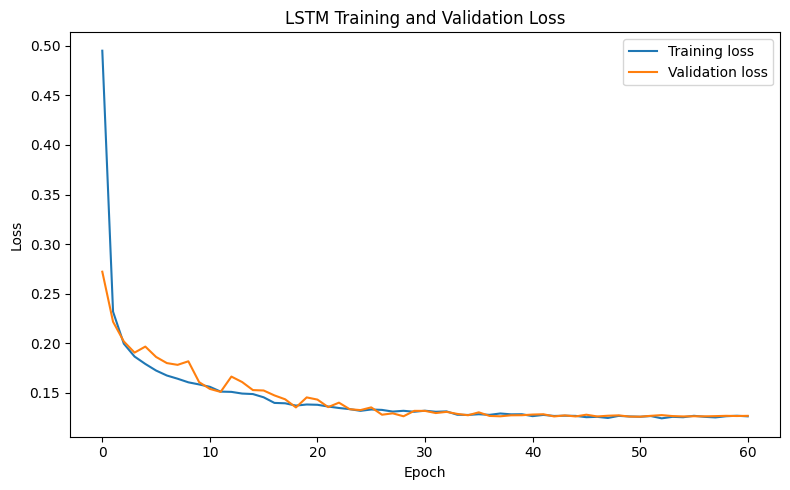

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training loss",
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss",
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

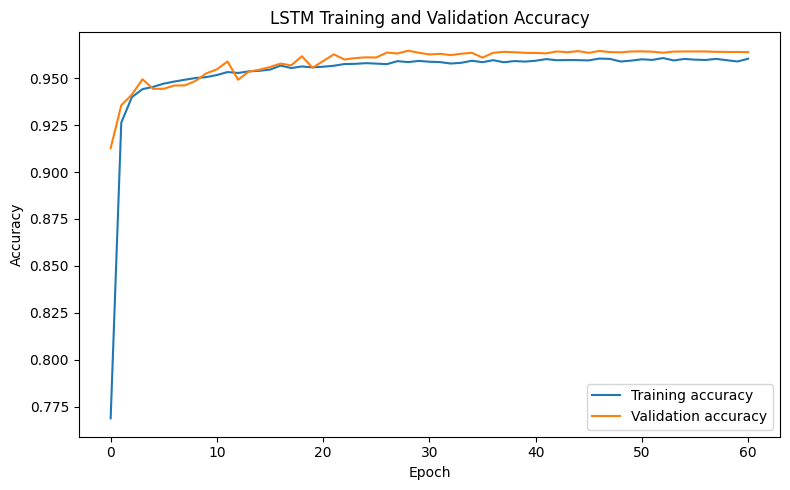

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training accuracy",
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy",
)

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
validation_probabilities = model.predict(
    {
        "photometric_bands": X_validation_bands,
        "redshift": X_validation_redshift,
    },
    verbose=0,
)

validation_predictions = np.argmax(
    validation_probabilities,
    axis=1,
)

validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions,
)

validation_macro_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="macro",
)

print(
    f"Validation accuracy: {validation_accuracy:.4f}"
)

print(
    f"Validation macro F1: {validation_macro_f1:.4f}"
)

print()
print(
    classification_report(
        y_validation,
        validation_predictions,
        target_names=label_encoder.classes_,
        digits=4,
    )
)

Validation accuracy: 0.9643
Validation macro F1: 0.9597

              precision    recall  f1-score   support

      GALAXY     0.9802    0.9594    0.9697      8917
         QSO     0.9067    0.9392    0.9226      2844
        STAR     0.9738    1.0000    0.9867      3239

    accuracy                         0.9643     15000
   macro avg     0.9536    0.9662    0.9597     15000
weighted avg     0.9649    0.9643    0.9644     15000



In [ ]:
test_loss, test_keras_accuracy = model.evaluate(
    {
        "photometric_bands": X_test_bands,
        "redshift": X_test_redshift,
    },
    y_test,
    verbose=0,
)

test_probabilities = model.predict(
    {
        "photometric_bands": X_test_bands,
        "redshift": X_test_redshift,
    },
    verbose=0,
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1,
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions,
)

test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test macro F1: {test_macro_f1:.4f}")
print()

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_,
        digits=4,
    )
)

Test loss: 0.1270
Test accuracy: 0.9637
Test macro F1: 0.9591

              precision    recall  f1-score   support

      GALAXY     0.9830    0.9558    0.9692      8917
         QSO     0.9034    0.9469    0.9246      2844
        STAR     0.9672    1.0000    0.9833      3239

    accuracy                         0.9637     15000
   macro avg     0.9512    0.9676    0.9591     15000
weighted avg     0.9645    0.9637    0.9638     15000



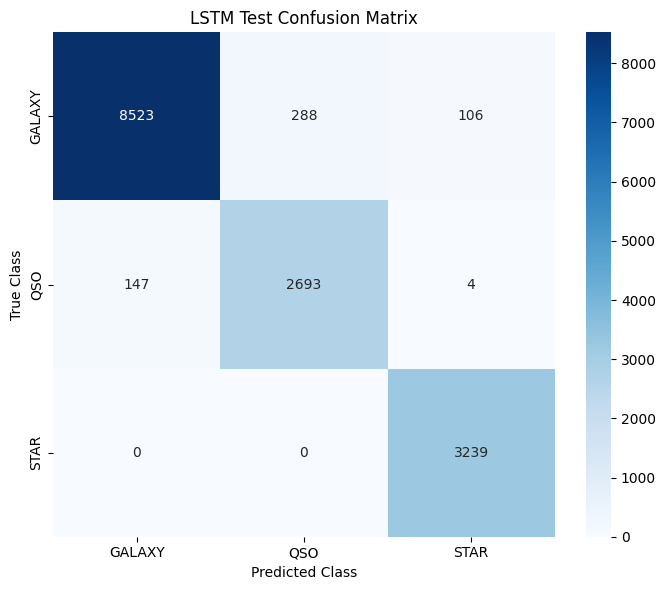

In [ ]:
test_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions,
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)

plt.title("LSTM Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

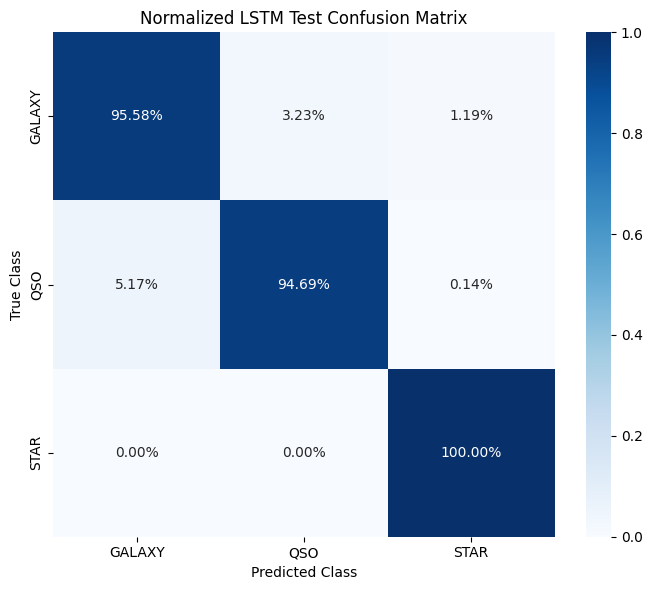

In [ ]:
normalized_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions,
    normalize="true",
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    normalized_confusion_matrix,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)

plt.title("Normalized LSTM Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

In [ ]:
OUTPUT_DIRECTORY = Path("lstm_outputs")
OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

In [ ]:
model.save(
    OUTPUT_DIRECTORY / "stellar_lstm.keras"
)

joblib.dump(
    band_scaler,
    OUTPUT_DIRECTORY / "band_scaler.joblib",
)

joblib.dump(
    redshift_scaler,
    OUTPUT_DIRECTORY / "redshift_scaler.joblib",
)

joblib.dump(
    label_encoder,
    OUTPUT_DIRECTORY / "label_encoder.joblib",
)

print("Model and preprocessing objects saved.")

Model and preprocessing objects saved.
